# HDT 2 - Visión Por Computadora

Autores:

- Nelson García
- Joaquín Puente
- Diego Linares

Repo: https://github.com/Its-Japo/VisionXComputadora/tree/main/HDT_2

# Task 1 - Análisis

## Respuestas

1. **No** es un enfoque correcto para medir distancia 3D con una escena general. Porque durante una rotación pura del robot, los centros de cámara cumplen C1 = C2, por lo que la línea base es B = 0 y no hay paralaje geométrico útil para triangulación.

   La homografía describe bien el mapeo entre vistas cuando la escena es plana (o cuando solo hay rotación), pero no recupera profundidad absoluta Z de objetos arbitrarios en 3D.
   En resumen: con rotación pura, homografías sirven para registrar/alinear imágenes, no para estimar distancia métrica a cajas en distintos planos.

2. Si en traslación la disparidad de una caja sube bruscamente entre t y t+1, entonces la distancia Z disminuyó (la caja está más cerca).
   En estéreo rectificado se usa: Z = (f * B) / d, así que mayor d implica menor Z.
   Riesgo industrial de error en d:
   - Si se subestima d (se sobreestima Z), el robot cree que la caja está lejos y puede no frenar a tiempo (colisión, daño a producto/estantería, riesgo humano).
   - Si se sobreestima d (se subestima Z), hay frenados/paradas falsas, pérdida de throughput y bloqueos operativos.
   Por seguridad, este cálculo debe validarse con calibración estéreo, chequeos temporales y límites de frenado conservadores.

# Task 2 – Ingeniería de Dimensiones

1. Utilizando la fórmula vista en clase, calcule las dimensiones (Wout,Hout) del Mapa de Características
resultante. Muestra el procedimiento.

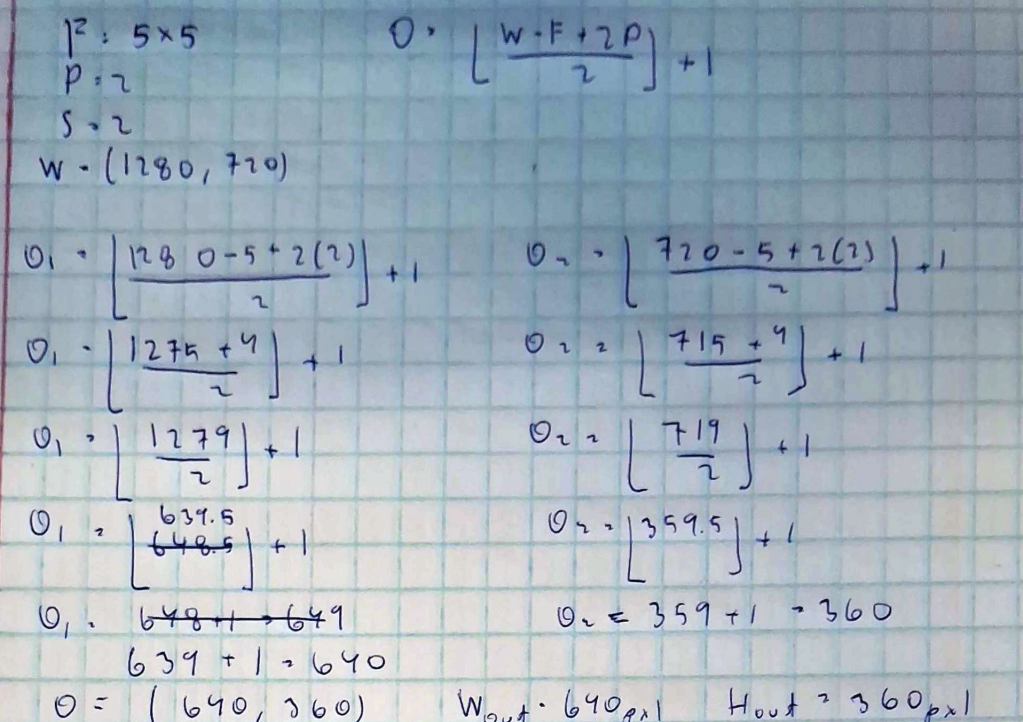

2. ¿Qué sucedería con el tamaño de la salida si decides cambiar el Padding a P=0 (Valid Padding)?


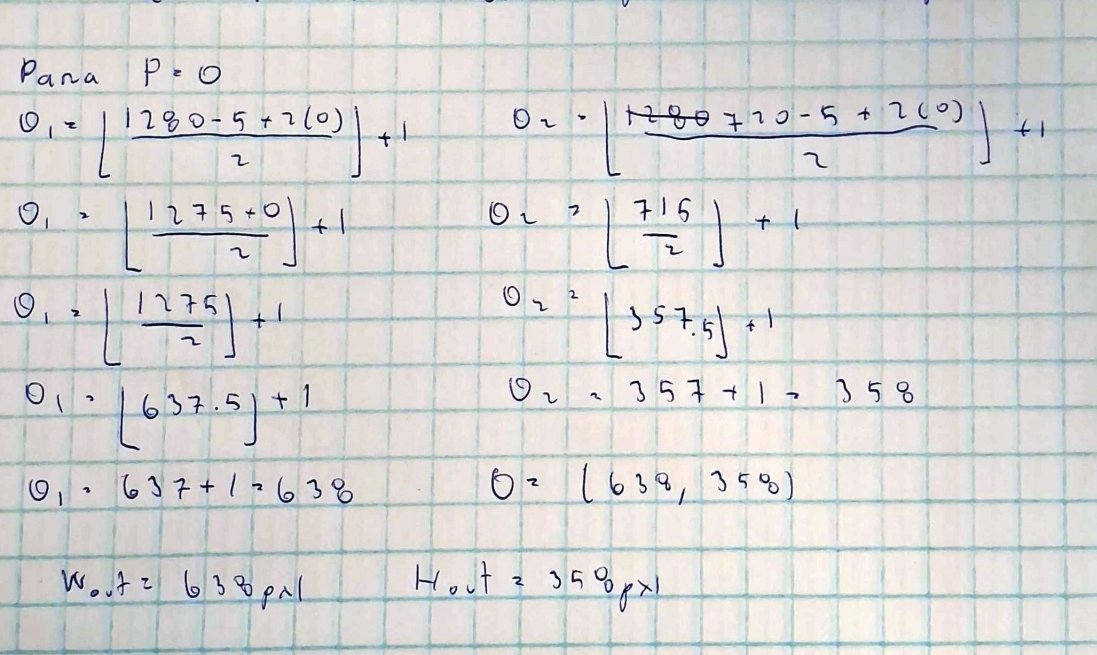

¿Cómo afectaría esto a la información de los bordes de la imagen (donde suelen estar las referencias
de las paredes del almacén)?

Si se usa Padding = 0:

El filtro no puede aplicarse en los bordes de la imagen. Se pierden algunos píxeles en las zonas externas. Esto provoca que información importante cerca de los bordes desaparezca. Las paredes del almacén, que suelen estar cerca de los bordes de la imagen, podrían no ser detectadas correctamente y cometer errores a la hora de recoger productos. El modelo perdería referencias espaciales importantes.

En cambio, con Padding = 2:

Se agregan píxeles alrededor de la imagen. El filtro puede analizar también las esquinas y bordes. Se preserva mejor la información espacial.

# Task 3 – Criterio de Diseño

## Respuestas Task 3

1. **Detección de grietas microscópicas (prioridad: precisión):**
   - Recomendaría en las primeras capas: Stride = 1 y sin pooling agresivo (idealmente sin pooling en bloque 1, o MaxPooling 2x2 recién después de 2-3 convoluciones).
   - Justificación: las grietas finas son patrones de alta frecuencia; si se submuestrea temprano se pierde detalle espacial crítico y baja la sensibilidad del detector.
   - En práctica: usar kernels pequeños (3x3), más profundidad en etapas tempranas y reducción de resolución de forma gradual.

2. **Procesador limitado (prioridad: velocidad/memoria):**
   - Aplicar Stride > 1 estratégicamente en una convolución temprana (por ejemplo, en la 2da capa) para bajar resolución y costo computacional.
   - Usar Max Pooling 2x2, stride 2 en puntos puntuales para conservar activaciones fuertes (bordes/defectos dominantes) mientras se reduce RAM y FLOPs.
   - Evitar encadenar demasiadas reducciones seguidas al inicio; mejor combinar: conv s=1 -> conv s=2 -> maxpool según presupuesto, verificando que no caiga el recall de defectos pequeños.
   - Si el límite es muy estricto, complementar con Global Average Pooling al final para evitar capas densas grandes.


# Task 4 – Implementación Práctica



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:

def manual_convolution(image, kernel, stride=1, padding=0):
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)

    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError("image y kernel deben ser matrices 2D.")
    if kernel.shape[0] != kernel.shape[1]:
        raise ValueError("El kernel debe ser cuadrado (N x N).")
    if stride <= 0:
        raise ValueError("stride debe ser >= 1.")
    if padding < 0:
        raise ValueError("padding debe ser >= 0.")

    H, W = image.shape
    N = kernel.shape[0]

    padded = np.pad(image, pad_width=padding, mode="constant", constant_values=0)
    H_p, W_p = padded.shape

    H_out = (H_p - N) // stride + 1
    W_out = (W_p - N) // stride + 1
    if H_out <= 0 or W_out <= 0:
        raise ValueError("Kernel/padding/stride incompatibles: salida no válida.")

    out = np.zeros((H_out, W_out), dtype=float)

    out_i = 0
    for i in range(0, H_p - N + 1, stride):
        out_j = 0
        for j in range(0, W_p - N + 1, stride):
            window = padded[i:i+N, j:j+N]
            out[out_i, out_j] = np.sum(window * kernel)
            out_j += 1
        out_i += 1

    return out

def normalize_for_display(x):
    x = x.astype(np.float32)
    mn, mx = x.min(), x.max()
    if mx - mn < 1e-8:
        return np.zeros_like(x, dtype=np.uint8)
    x = (x - mn) * (255.0 / (mx - mn))
    return x.astype(np.uint8)


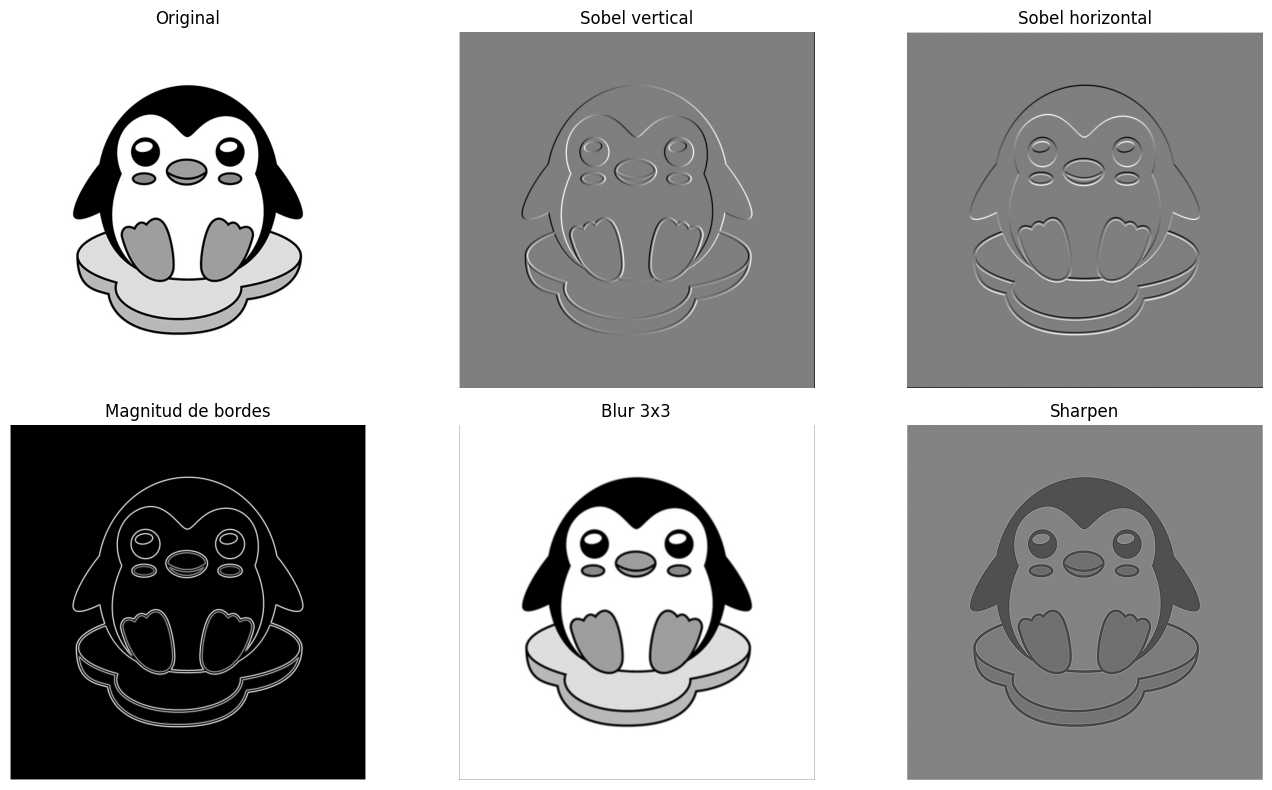

In [3]:

# Cargar imagen 
img_bgr = cv2.imread("pinguino.jpg")

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Definir kernels 
sobel_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=float)

sobel_horizontal = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=float)

blur_3x3 = (1/9) * np.ones((3, 3), dtype=float)

sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=float)

# Aplicar convoluciones manuales
edges_v = manual_convolution(img_gray, sobel_vertical, stride=1, padding=1)
edges_h = manual_convolution(img_gray, sobel_horizontal, stride=1, padding=1)
blurred = manual_convolution(img_gray, blur_3x3, stride=1, padding=1)
sharpened = manual_convolution(img_gray, sharpen, stride=1, padding=1)

edge_magnitude = np.sqrt(edges_v**2 + edges_h**2)

disp_original = img_gray
disp_edges_v = normalize_for_display(edges_v)
disp_edges_h = normalize_for_display(edges_h)
disp_blur = normalize_for_display(blurred)
disp_sharp = normalize_for_display(sharpened)
disp_mag = normalize_for_display(edge_magnitude)

# Mostrar resultados
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.ravel()

axs[0].imshow(disp_original, cmap="gray")
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(disp_edges_v, cmap="gray")
axs[1].set_title("Sobel vertical")
axs[1].axis("off")

axs[2].imshow(disp_edges_h, cmap="gray")
axs[2].set_title("Sobel horizontal")
axs[2].axis("off")

axs[3].imshow(disp_mag, cmap="gray")
axs[3].set_title("Magnitud de bordes")
axs[3].axis("off")

axs[4].imshow(disp_blur, cmap="gray")
axs[4].set_title("Blur 3x3")
axs[4].axis("off")

axs[5].imshow(disp_sharp, cmap="gray")
axs[5].set_title("Sharpen")
axs[5].axis("off")

plt.tight_layout()
plt.show()

En una operación de convolución, un kernel se desplaza sobre la imagen de entrada realizando un producto punto entre los valores del kernel y los píxeles cubiertos por la ventana.  
Cada resultado se almacena en el Feature Map.

El desplazamiento del kernel está controlado por el parámetro Stride ($S$), el cual determina cuántos píxeles se mueve el filtro en cada paso.

Cálculo del tamaño del mapa de características

El tamaño de la salida de una convolución se calcula mediante la siguiente fórmula, como se vió el el Task 2:

$$
O = \left\lfloor \frac{W - F + 2P}{S} \right\rfloor + 1
$$

donde:

- $W$ = tamaño de la imagen de entrada  
- $F$ = tamaño del filtro (kernel)  
- $P$ = padding  
- $S$ = stride  
- $O$ = tamaño de la salida (feature map)  
- $\lfloor \cdot \rfloor$ = función piso  

Esta fórmula se aplica tanto para el ancho como para la altura del mapa de características.

---

#### Caso 1: Stride $S = 1$

Cuando el stride es 1, el kernel se desplaza pixel por pixel sobre la imagen.

Esto implica que:

- Se generan más posiciones de cálculo.
- El Feature Map conserva mayor resolución.
- El tamaño de salida es relativamente grande.

---

#### Caso 2: Stride $S = 2$

Cuando el stride es mayor que 1, el kernel salta posiciones al desplazarse.

En este caso:

- El filtro se aplica menos veces sobre la imagen.
- Se generan menos valores en el mapa de características.
- La resolución espacial de la salida disminuye.

En muchos casos, utilizar $S = 2$ reduce aproximadamente a la mitad las dimensiones espaciales del feature map.

---
